In [1]:
# https://github.com/huggingface/transformers/blob/v4.57.0/src/transformers/models/maskformer/modeling_maskformer.py
import torch
from torchvision import models
import matplotlib.pyplot as plt

In [ ]:
# maskformer

# Stable release
!pip install scipy
!pip install numpy==1.26.4
!pip install transformers
# If you want PyTorch + Transformers
!pip install torch torchvision transformers

In [2]:
# dataloader

print('This will give you dataset of ade20k challenge with 150')

import importlib
import data.ade20k_challenges
importlib.reload(data.ade20k_challenges)
from data.ade20k_challenges import ADE20k_challange
from torchvision import transforms, datasets
from torchvision.transforms import InterpolationMode

im_size = 640
print('im_size should be 640 for maskformer  else 512')

transform_train_no_np = transforms.Compose([
    transforms.Resize((im_size, im_size),  interpolation=InterpolationMode.NEAREST),  # Resize the image
    transforms.PILToTensor()  # Convert to uint8 tensor array [c, h, w]
])

dataset_train = ADE20k_challange('dataset/ADEChallengeData2016/' , transform=transform_train_no_np, data_set = 'training',
                                 color_pallete = None, img_size = im_size, aug = False)
batch_size = 16
trainloader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)
# label number to label classese
# https://docs.google.com/spreadsheets/d/1se8YEtb2detS7OuPE86fXGyD269pMycAWe2mtKUj2W8/edit?gid=0#gid=0

This will give you dataset of ade20k challenge with 150
im_size should be 640 for maskformer  else 512


In [3]:
# CocoStuff 164k MAhmed
# batch 32 works in edith server
print('This will give you dataset of Coco164k with 182 labels')

import importlib
import data.cocostuff
importlib.reload(data.cocostuff)
from data.cocostuff import COCOStuff164k

dataset_train = COCOStuff164k('dataset/cocostuff164k/' , transform=transform_train_no_np, data_set = 'train2017',
                               img_size = im_size, aug = False)
batch_size = 16
trainloader = torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True, pin_memory=True, drop_last=True)
# label number to label classese
# https://github.com/nightrome/cocostuff/blob/master/labels.txt

This will give you dataset of Coco164k with 182 labels


In [ ]:
#wild dash dataset (Masud) to be Varified Later
transform_train_no_np = transforms.Compose([
    transforms.Resize((640, 640),  interpolation=InterpolationMode.NEAREST),    # Resize the image
    transforms.PILToTensor()  # Convert to uint8 tensor array [c, h, w]
])
dataset_train = WildDash('dataset/WildDash/' , transform=transform_train_no_np, data_set = 'rs19_val',color_pallete = None, img_size = 640, aug = False)

In [4]:
import data.augmentation_script
import data.ade20k
importlib.reload(data.augmentation_script)
importlib.reload(data.ade20k)
from data.augmentation_script import _augmentation_gpu

In [5]:
# imagenet preprecessing (the input should be value of to 0-1)
dl_preprocess = transforms.Compose([
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225]),
])
device = 'cuda'

In [6]:
# maskformer model experiments
print('This is for MaskFormer Model')
import transformers
from transformers import AutoImageProcessor, MaskFormerForInstanceSegmentation, MaskFormerPreTrainedModel, MaskFormerModel
from transformers.utils import ModelOutput
from PIL import Image
import requests
from transformers import MaskFormerConfig
# Example: ADE20K variant
config = MaskFormerConfig.from_pretrained("facebook/maskformer-swin-base-ade")

# load MaskFormer fine-tuned on ADE20k semantic segmentation
image_processor = AutoImageProcessor.from_pretrained("facebook/maskformer-swin-base-ade")

#%% using manual steps. # way faster than the earlier one.
# should be identical to the earlier processing input

# maskformer input processing 

import sys
sys.path.append('..')  # relative to notebook location
import maskformer_models
importlib.reload(maskformer_models)
from maskformer_models import maskformer_label_gen_gpu
# (inputs.pixel_values - pixel_values).abs() < 1e-4


This is for MaskFormer Model


In [7]:
# mask2former model experiments
print('This is for Mask 2 Former Model: dont run this for maskformer model')

from transformers import Mask2FormerForUniversalSegmentation,  AutoImageProcessor

image_processor = AutoImageProcessor.from_pretrained("facebook/mask2former-swin-large-ade-semantic")
image_processor.do_random_crop = False
image_processor.size = {"height": 640, "width": 640}
image_processor.do_resize = True



This is for Mask 2 Former Model: dont run this for maskformer model


In [8]:
# model_name = "facebook/maskformer-swin-large-coco" ;  print("maskformer - cocostuff")
# model_name = "facebook/maskformer-swin-base-coco"
# model_name = "facebook/maskformer-swin-base-ade" ; print("maskformer - ade20K")

# below is the mask2former model
model_name =  "facebook/mask2former-swin-base-coco-instance"; print("mask 2 former")

# model_name =  "facebook/mask2former-swin-base-ade-semantic"; print("mask 2 former")
# model_name =  "facebook/mask2former-swin-large-ade-semantic" ; print("mask 2 former")


mask 2 former


In [ ]:
# custom maskformer model design

print('This is for MaskFormer Model: dont run if for the mask2former Model')
importlib.reload(maskformer_models)
import torch.nn as nn

import sys
sys.path.append('..')  # relative to notebook location
from MERU_utils import lorentz as L
importlib.reload(L)

from transformers.models.maskformer.modeling_maskformer import MaskFormerLoss
from transformers.models.maskformer.modeling_maskformer import MaskFormerHungarianMatcher

class CustomMaskFormerLoss(MaskFormerLoss):
    """
    A subclass of MaskFormerLoss for custom modifications.
    You can override methods like `forward` or add new loss components.
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # You can add your custom initialization here later

    def forward(self, *args, **kwargs):
        # For now, just call the base class forward
        return super().forward(*args, **kwargs)


from maskformer_models import MeruMaskFormer



config = MaskFormerConfig.from_pretrained(model_name)

# load option 1
new_model = MeruMaskFormer.from_pretrained(
    model_name,
    config= config)

# re-initialize the extra paprameters
# text_feats_pca = torch.load("class_embeddings_word/Ade_20k_AutoEncoder_bse1_5_256D.pt")
text_feats_pca = torch.load("class_embeddings_word/Ade_151_pca_bse1_5_64D.pt")
# text_feats_pca = torch.load("class_embeddings_word/Coco_183_pca_bse1_5_64D.pt")

text_feats = text_feats_pca.squeeze(dim = 1)
new_model.text_protos = nn.Parameter(text_feats.clone(), requires_grad = False) 
# weights for multiplication
new_model.textual_alpha = nn.Parameter(torch.tensor(0.3**-1).log(), requires_grad = False) # norm value for TEXT (need checking for 256)
new_model.transformer_alpha =  nn.Parameter(torch.tensor(5**-1).log(), requires_grad = True) # norm value for transformer outputs
new_model.pixel_alpha =  nn.Parameter(torch.tensor(20**-1).log(), requires_grad = True) # norm value for IMAGE pixel decoder output
new_model.mask_alpha =  nn.Parameter(torch.tensor(5**-1).log(), requires_grad = True) # norm value for Mask Embedding outputs

new_model.criterion = CustomMaskFormerLoss(
            150, #config.num_labels, # 182 [#(for coco)]  # 150 [#(for Ade)]
            matcher=new_model.matcher,
            weight_dict=new_model.weight_dict,
            eos_coef=config.no_object_weight)

# exptected output: Some weights of MeruMaskFormer were not initialized from the model checkpoint at facebook/maskformer-swin-base-ade and are newly initialized: ['text_protos']
# You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
new_model.mask_alpha.exp()


# new_model.criterion

In [9]:
# custom mask 2 former model design

print('This is for Mask 2 Former Model: dont run if for the maskformer Model')

import mask2former_models
importlib.reload(mask2former_models)
import mask2former_models
import torch.nn as nn
import sys
sys.path.append('..')  # relative to notebook location
from MERU_utils import lorentz as L
importlib.reload(L)

from transformers import Mask2FormerForUniversalSegmentation, Mask2FormerConfig
from transformers.models.mask2former.modeling_mask2former import Mask2FormerMaskPredictor, Mask2FormerLoss, Mask2FormerHungarianMatcher


# Example: ADE20K variant
config = Mask2FormerConfig.from_pretrained(model_name)


class CustomMask2FormerLoss(Mask2FormerLoss):
    """
    A subclass of MaskFormerLoss for custom modifications.
    You can override methods like `forward` or add new loss components.
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        # You can add your custom initialization here later

    def forward(self, *args, **kwargs):
        # For now, just call the base class forward
        return super().forward(*args, **kwargs)


from mask2former_models import MeruMask2Former, MeruMask2Predictor


new_model =  MeruMask2Former.from_pretrained(model_name, config = config)
# model = model.to(device)

# enabling MeruMaskPredictor Head
orig_pred = new_model.model.transformer_module.decoder.mask_predictor
new_pred = MeruMask2Predictor(
    hidden_size=new_model.config.hidden_dim,
    num_heads=new_model.config.num_attention_heads,
    mask_feature_size=new_model.model.transformer_module.decoder.mask_feature_size, # config.mask_feature_size
)


    
new_pred.load_state_dict(orig_pred.state_dict(),     strict=False) # load weight
new_model.model.transformer_module.decoder.mask_predictor = new_pred #load the new mask_predictor


# re-initialize the extra paprameters
# text_feats_pca = torch.load("class_embeddings_word/Ade_20k_AutoEncoder_bse1_5_256D.pt")
# text_feats_pca = torch.load("class_embeddings_word/Ade_151_pca_bse1_5_64D.pt")
text_feats_pca = torch.load("class_embeddings_word/Coco_183_pca_bse1_5_64D.pt")

text_feats = text_feats_pca.squeeze(dim = 1)
new_model.text_protos = nn.Parameter(text_feats.clone(), requires_grad = False) 

new_model.textual_alpha = nn.Parameter(torch.tensor(0.3**-1).log(), requires_grad = False) # norm value for TEXT (need checking for 256)
new_model.transformer_alpha =  nn.Parameter(torch.tensor(5**-1).log(), requires_grad = True) # norm value for transformer outputs


config.num_labels = 182     #        150, #config.num_labels, # 182 [#(for coco)]  # 150 [#(for Ade)]

new_model.criterion = CustomMask2FormerLoss(config=config, weight_dict=new_model.weight_dict)

    
# over-write config.num_labels = value# if necessary
# or new_model.criterion.num_labels = value#
#checking code

# new_model.model.transformer_module.decoder.layers[0].self_attn.k_proj.weight
# model.model.transformer_module.decoder.layers[0].self_attn.k_proj.weight
# model.model.transformer_module.decoder.mask_predictor.mask_embedder.layers[0].layers[0].weight

new_model = new_model.to(device)



This is for Mask 2 Former Model: dont run if for the maskformer Model


Loading weights:   0%|          | 0/782 [00:00<?, ?it/s]

MeruMask2Former LOAD REPORT from: facebook/mask2former-swin-base-coco-instance
Key                    | Status  | 
-----------------------+---------+-
textual_alpha          | MISSING | 
class_projector.bias   | MISSING | 
transformer_alpha      | MISSING | 
text_protos            | MISSING | 
class_projector.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [87]:
print("hyperbolicity test: delete it later")
new_model = new_model.to(device)

data_iterator = iter(trainloader)
inputs, labels, _ = next(data_iterator)

inputs = inputs.to(device)
#inputs processing 

inputs = dl_preprocess(inputs.float()/255.0).to(device) 

with torch.no_grad():
    outputs = new_model(inputs)       # outputs is a dict
    # outputs = new_model.model.pixel_level_module(inputs)
        

hyperbolicity test: delete it later


In [10]:
# define optimizer for the maskformer model

print("Maskformer/Mask2former model optimizer")
# define the model in the 
model = new_model.to(device)

# Define parameter groups
import torch.optim as optim

lr1 = 2e-4
lr2 = 4e-4

param_groups = []
all_params = list(model.parameters())
added_params = set()

def add_params(mod, lr):
    for p in mod.parameters():
        if p not in added_params:
            param_groups.append({"params": [p], "lr": lr})
            added_params.add(p)

# Custom groups
if hasattr(model, "model"):
    add_params(model.model, lr1)
if hasattr(model, "mask_embedder"):
    add_params(model.mask_embedder, lr2)
if hasattr(model, "class_projector"):
    add_params(model.class_projector, lr2)

# Add any remaining parameters not covered
for p in model.parameters():
    if p not in added_params:
        param_groups.append({"params": [p], "lr": lr1})

optimizer = optim.SGD(param_groups, momentum=0.9, weight_decay=1e-4)


# Optional sanity check
covered = sum(p.numel() for g in optimizer.param_groups for p in g["params"])
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Covered parameters: {covered}/{total} ({covered/total:.2%})")

# Optional: list groups and learning rates
# for i, g in enumerate(optimizer.param_groups):
#     print(f"Group {i}: lr={g['lr']}, num_params={len(g['params'])}")


Maskformer/Mask2former model optimizer
✅ Covered parameters: 106932365/106920652 (100.01%)


In [11]:
importlib.reload(maskformer_models)
from maskformer_models import maskformer_label_gen_gpu
importlib.reload(L)

<module 'MERU_utils.lorentz' from '/notebooks/sam_1/segment-anything/MERU_utils/lorentz.py'>

In [ ]:
# training Loop Maskformer

print('Training loop for hyperbolic Meru Model: modified: this works for all')
# model should be MeruDeepLabV3 class
import random
import pdb
im_size = 640


for epoch in range(1):  # loop over the dataset multiple times    
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        try:
            inputs, labels  = data
        except: 
            inputs, labels, _ = data
        inputs = inputs.to(device)
        labels = labels.squeeze().to(device)
        inputs, labels  = _augmentation_gpu(inputs.float(), labels, augmentation_num = random.randint(0, 0), im_size= im_size) # input -> bs, 3, h, w ; labels -> bs, h, w
        
        #inputs processing 
        
        inputs = dl_preprocess(inputs.float()/255.0).to(device) 
        
        #label processing 
        labels = labels.long().to(device)
        mask_labels, class_labels = maskformer_label_gen_gpu(labels, device = device) 
        
        
        optimizer.zero_grad()

        outputs = model(pixel_values = inputs, mask_labels = mask_labels, class_labels = class_labels)          # outputs is a dict
        
        loss = outputs["loss"]

        if torch.isnan(loss):
            print(f"[NaN Detected] Epoch {epoch} Step {step}")
            print("Logging:", outputs.get("logging", {}))
            pdb.set_trace()   # drop into debugger

        loss.backward()
        
        optimizer.step()

        running_loss += loss.item()   

        if i% 100 ==0:
            with torch.no_grad():
                # pred = model(inputs, None).permute(0,3,1,2) # ["logits"] #
                # pred = torch.argmax(pred, dim=1)
                # Check if predictions match the ground truth (shape: B, H, W)
                # correct = (pred == labels).float()  # Convert to float to compute mean
                # Compute the pixel-wise accuracy
                # accuracy = correct.sum() / (labels.numel())  # numel() gives total number of elements
                # print('Accuracy: ', accuracy)
                print('loss value: ', loss.item())
                
print('Finished Training')

Training loop for hyperbolic Meru Model: modified: this works for all
loss value:  43.061767578125


In [32]:
print('finished training')

finished training


In [78]:
input('checking if you want to save it: Abort for no saving'); 
PATH = 'saved_models/MERU_mask_2_former_angle_dist_coco.pth'
torch.save(model.state_dict(), PATH)
# model.load_state_dict(torch.load(PATH, map_location=device))  # load weight
# state_dict = torch.load(PATH, map_location=device)
# missing, unexpected = model.load_state_dict(state_dict, strict=False)

checking if you want to save it: Abort for no saving 


In [33]:
# post processing

# maskformer experiments: data post processing for visualization: may need to be revised afterward

import torch.nn.functional as F

def manual_post_process_instance_segmentation(outputs, target_size, threshold=0.5):
    class_logits = outputs.class_queries_logits
    mask_logits  = outputs.masks_queries_logits

    class_probs = class_logits.softmax(-1)[..., :-1]  # remove no-object
    scores, labels = class_probs.max(-1)              # best class per query

    # Upsample masks to target size
    mask_probs = F.interpolate(
        mask_logits, size=target_size, mode="bilinear", align_corners=False
    ).sigmoid()

    # Filter by confidence
    keep = scores[0] > threshold
    scores = scores[0, keep]
    labels = labels[0, keep]
    masks  = mask_probs[0, keep]   # (num_kept, H, W)

    # Optional binarization
    binary_masks = (masks > 0.5).float()

    return {
        "scores": scores,
        "labels": labels,
        "masks": binary_masks,
    }


def manual_post_process_semantic_segmentation(outputs, target_size):
    class_logits = outputs.class_queries_logits   # (B, Q, C+1)
    mask_logits  = outputs.masks_queries_logits   # (B, Q, h, w)
    
    # mask_logits = h_m.permute(0,3,1,2) # hyperbolic mask output

    class_probs = class_logits.softmax(-1)[..., :-1]  # drop "no-object"
    mask_probs  = mask_logits.sigmoid()

    # Upsample masks to target resolution
    mask_probs = F.interpolate(mask_probs, size=target_size, mode="bilinear", align_corners=False)

    # Weighted sum across queries to get per-class logits
    # (B, C, H, W) = (B, Q, C)^T × (B, Q, H, W)
    semseg = torch.einsum("bqc,bqhw->bchw", class_probs, mask_probs)

    # Get argmax across classes
    segmentation = semseg.argmax(1)  # (B, H, W)
    return segmentation

In [89]:
results_is = manual_post_process_instance_segmentation(outputs, (640, 640))
results_ss = manual_post_process_semantic_segmentation(outputs, (640, 640))

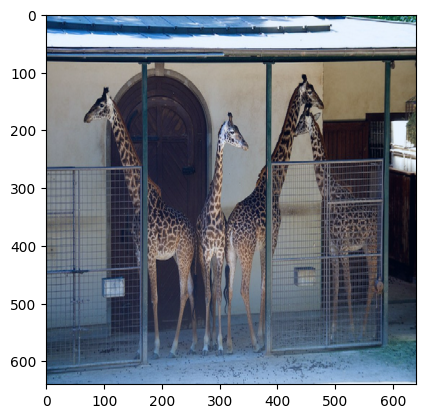

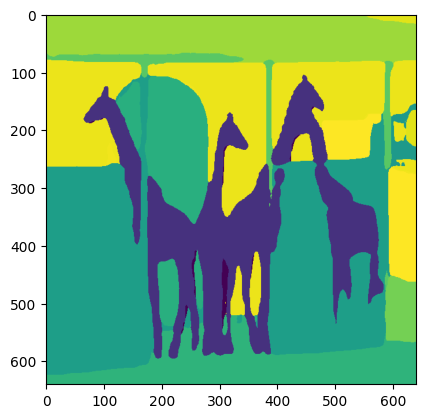

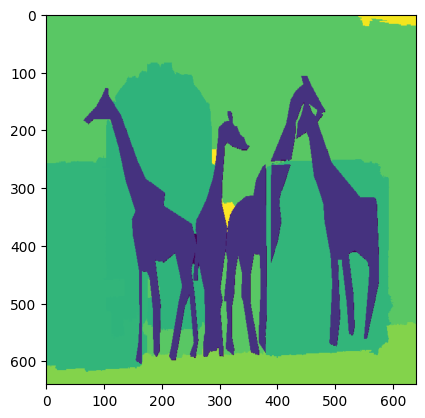

In [148]:
# plt.imshow(results_ss[0].cpu()) ; plt.show()
bs = 15
import matplotlib.pyplot as plt
input_to_plot = (inputs[bs] -  inputs[bs].min())/(inputs[bs].max() -  inputs[bs].min())
plt.imshow(input_to_plot.cpu().permute(1,2,0)); plt.show()
plt.imshow(results_ss[bs].cpu()); plt.show()
plt.imshow(labels[bs][0].cpu()); plt.show()

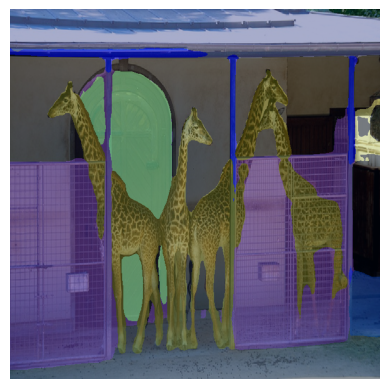

In [149]:
from Utils_Loss_Vis import image_gen
image_gen.image_gen(input_to_plot.cpu(), results_ss[bs].cpu(),  0.5, save_fig = 'coco3', palette = 'coco')

In [98]:
def entropy_over_classes(p):
    """
    p: tensor shape [B, Q, C] with softmax already applied.
    Returns: entropy per    [B, Q]
    """
    # Avoid log(0)
    p_safe = p.clamp(min=1e-12)
    # Entropy = -sum(p * log(p), dim=-1)
    ent = -(p_safe * p_safe.log()).sum(dim=-1)
    return ent   # shape [B, Q]

ent_val = entropy_over_classes(outputs.class_queries_logits[bs].softmax(-1))

In [38]:
torch.argsort(ent_val)
labels[bs].unique()

tensor([  0,   1,   3,  16,  41, 111, 149, 150, 155], device='cuda:0')

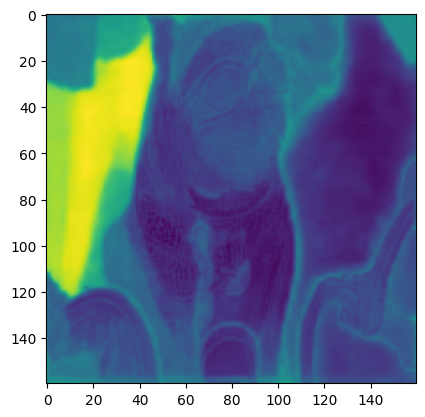

In [113]:
qurey_number =  92
inputs_= outputs.masks_queries_logits[:,qurey_number:qurey_number+1,:,:].detach()
input_to_plot = (inputs_[bs] -  inputs_[bs].min())/(inputs_[bs].max() -  inputs_[bs].min())
plt.imshow(input_to_plot.cpu().permute(1,2,0)); plt.show()

In [52]:
(outputs.class_queries_logits[bs].softmax(-1).argmax(-1) == 150).nonzero(as_tuple=True)[0]

tensor([92], device='cuda:0')

In [54]:
outputs.class_queries_logits[bs].softmax(-1).argmax(-1).unique()

tensor([  0,   1,   3,   8,  41,  92,  96, 105, 111, 140, 149, 150, 155, 157,
        182], device='cuda:0')

In [891]:
outputs.class_queries_logits[bs][:, 7].argmax()

tensor(6, device='cuda:0')

In [ ]:
# manual angle and distance calculation

print("Maskformer Interogation")

pixel_embeddings = outputs.pixel_decoder_last_hidden_state
l_p_d_f = L.exp_map0(pixel_embeddings.permute(0,2,3,1) * model.pixel_alpha.exp())  # lorentz pixel decoder features: shape of BS, h,w, feature-dim(256)
transformer_decoder_hidden_states = outputs.transformer_decoder_last_hidden_state  # shape of bs, 100, 256(d) # a 4d matrix
trans_dec_proj = model.class_projector(transformer_decoder_hidden_states)
l_t_d  = L.exp_map0(trans_dec_proj * model.transformer_alpha.exp()) # lorentz transformer_decoder_hidden_states # a 3d matrix  
l_tp = L.exp_map0(model.text_protos* model.textual_alpha.exp()) # lorentz text prototypes # shape of class_number, 256 (d) # a 2d matrix
classes_agl =  L.oxy_angle_full_gnr(l_t_d, l_tp) # angle with class text prototypes (bs, 100, class_number)
classes_dist = L.pairwise_dist(l_t_d, l_tp)
mask_embeddings = model.mask_embedder(transformer_decoder_hidden_states) # euclidean operation # not good idea to add another hyperbolic layer 
        # mask_embeddings = F.normalize(mask_embeddings,  p=2, dim=-1) # if normalized
l_m_e = L.exp_map0(mask_embeddings*model.mask_alpha.exp()) # lorentz mask embedding
angle_val, dist_val =  L.oxy_angle_mask(l_p_d_f, l_m_e) # raw value of angle and the distance (lower the better for each classes)

In [99]:
print("Mask 2 former Interogation")

with torch.no_grad():
    # outputs_om = model(pixel_values = pixel_values, mask_labels = mask_labels, class_labels = class_labels)
    # outputs_feat = model.model(pixel_values)
    pixel_level_module_output = model.model.pixel_level_module(inputs, output_hidden_states=False) 
    
    multi_scale_features=pixel_level_module_output.decoder_hidden_states
    mask_features=pixel_level_module_output.decoder_last_hidden_state
    output_hidden_states=True,
    output_attentions=False


    multi_stage_features = []
    multi_stage_positional_embeddings = []
    size_list = []

    for i in range(3):
        size_list.append(multi_scale_features[i].shape[-2:])
        multi_stage_positional_embeddings.append(
            model.model.transformer_module.position_embedder(
                multi_scale_features[i].shape, multi_scale_features[i].device, multi_scale_features[i].dtype, None
            ).flatten(2)
        )
        multi_stage_features.append(
            model.model.transformer_module.input_projections[i](multi_scale_features[i]).flatten(2)
            + model.model.transformer_module.level_embed.weight[i][None, :, None]
        )

        # Flatten (batch_size, num_channels, height, width) -> (height*width, batch_size, num_channels)
        multi_stage_positional_embeddings[-1] = multi_stage_positional_embeddings[-1].permute(2, 0, 1)
        multi_stage_features[-1] = multi_stage_features[-1].permute(2, 0, 1)

    _, batch_size, _ = multi_stage_features[0].shape

    # [num_queries, batch_size, num_channels]
    query_embeddings = model.model.transformer_module.queries_embedder.weight.unsqueeze(1).repeat(1, batch_size, 1)
    query_features = model.model.transformer_module.queries_features.weight.unsqueeze(1).repeat(1, batch_size, 1)
    
    
    hidden_states = query_features
    
    query_position_embeddings = query_embeddings
    encoder_hidden_states = multi_stage_features
    
    
    all_hidden_states = () 
    attentions =  None
    
    intermediate = ()

    intermediate_mask_predictions = ()

    intermediate_hidden_states = model.model.transformer_module.decoder.layernorm(query_features)
    intermediate += (intermediate_hidden_states,)

    predicted_mask, attention_mask = model.model.transformer_module.decoder.mask_predictor(
        intermediate_hidden_states, mask_features, size_list[0]
    )
    intermediate_mask_predictions += (predicted_mask,)
    
        
    for idx, decoder_layer in enumerate(model.model.transformer_module.decoder.layers):     
        
        if output_hidden_states:
            all_hidden_states += (hidden_states,)
            
        dropout_probability = torch.rand([])
        level_index = idx % 3
        
        where = (attention_mask.sum(-1) != attention_mask.shape[-1]).to(attention_mask.dtype)
        # Multiply the attention mask instead of indexing to avoid issue in torch.export.
        attention_mask = attention_mask * where.unsqueeze(-1)

        layer_outputs = decoder_layer(
            hidden_states,
            level_index,
            None,  # attention_mask
            multi_stage_positional_embeddings,
            query_position_embeddings,
            encoder_hidden_states,  # as a positional argument for gradient checkpointing
            encoder_attention_mask=attention_mask,
            output_attentions=output_attentions,)
        
        intermediate_hidden_states = model.model.transformer_module.decoder.layernorm(layer_outputs[0])

        if idx ==8:    
            mask_embeddings = model.model.transformer_module.decoder.mask_predictor.mask_embedder(intermediate_hidden_states.transpose(0, 1))
                    # mask_embeddings = F.normalize(mask_embeddings,  p=2, dim=-1) # if normalized
            l_p_d_f = L.exp_map0(mask_features.permute(0,2,3,1) * model.model.transformer_module.decoder.mask_predictor.pixel_alpha.exp()) 
            l_m_e = L.exp_map0(mask_embeddings*model.model.transformer_module.decoder.mask_predictor.mask_alpha.exp()) # lorentz mask embedding
            angle_val, dist_val =  L.oxy_angle_mask(l_p_d_f, l_m_e) # raw value of angle and the distance (lower the better for each classes)
            print("Gotcha: not permuted values")

        predicted_mask, attention_mask = model.model.transformer_module.decoder.mask_predictor(
            intermediate_hidden_states,
            mask_features,
            size_list[(idx + 1) % 3],
        )

        intermediate_mask_predictions += (predicted_mask,)
        # add intermediate hidden states with layer norm applied which will be used for predicting class logits
        intermediate += (intermediate_hidden_states,)

        hidden_states = layer_outputs[0]

        if output_attentions:
            attentions += (layer_outputs[1],)
            
            
    # class logit findings 
    class_queries_logits = ()
    for decoder_output in intermediate:
        trans_dec_proj = model.class_projector(decoder_output.transpose(0, 1))
        l_t_d  = L.exp_map0(trans_dec_proj * model.transformer_alpha.exp()) # lorentz transformer_decoder_hidden_states # a 3d matrix  
        l_tp = L.exp_map0(model.text_protos* model.textual_alpha.exp()) # lorentz text prototypes # shape of class_number, 256 (d) # a 2d matrix
        # angle: text to class logits
        classes_agl =  L.oxy_angle_full_gnr(l_t_d, l_tp) # angle with class text prototypes (bs, 100, class_number)
        # alternatively distance
        classes_dist = L.pairwise_dist(l_t_d, l_tp)

        classes = classes_agl + 0.5*classes_dist # combination of the distance and angles

        class_prediction = - classes/0.08 
        class_queries_logits += (class_prediction,)

Mask 2 former Interogation
Gotcha: not permuted values


In [100]:
class_queries_logits[-1].shape
classes_agl[bs][:, 7].sort()
# mask_embeddings = F.normalize(mask_embeddings,  p=2, dim=-1) # in that case make the self.mask_alpha = 1 . log..
# mask_embeddings[0].pow(2).sum(-1)

torch.return_types.sort(
values=tensor([2.8409, 2.8554, 2.8560, 2.8591, 2.8602, 2.8664, 2.8711, 2.8743, 2.8753,
        2.8753, 2.8759, 2.8759, 2.8764, 2.8770, 2.8780, 2.8784, 2.8785, 2.8787,
        2.8789, 2.8792, 2.8795, 2.8798, 2.8801, 2.8802, 2.8805, 2.8808, 2.8811,
        2.8811, 2.8814, 2.8814, 2.8814, 2.8815, 2.8820, 2.8839, 2.8847, 2.8855,
        2.8855, 2.8857, 2.8872, 2.8874, 2.8876, 2.8879, 2.8909, 2.8919, 2.8919,
        2.8920, 2.8925, 2.8929, 2.8930, 2.8944, 2.8945, 2.8951, 2.8951, 2.8954,
        2.8959, 2.8959, 2.8960, 2.8966, 2.8971, 2.8975, 2.8980, 2.8980, 2.8984,
        2.8986, 2.8990, 2.8992, 2.8993, 2.8993, 2.8998, 2.9005, 2.9007, 2.9007,
        2.9008, 2.9013, 2.9018, 2.9021, 2.9021, 2.9022, 2.9023, 2.9023, 2.9025,
        2.9027, 2.9029, 2.9029, 2.9032, 2.9038, 2.9039, 2.9043, 2.9044, 2.9049,
        2.9061, 2.9063, 2.9079, 2.9086, 2.9100, 2.9108, 2.9145, 2.9155, 2.9178,
        2.9189], device='cuda:0'),
indices=tensor([93, 75, 35, 38, 25, 95, 44, 21, 39, 3

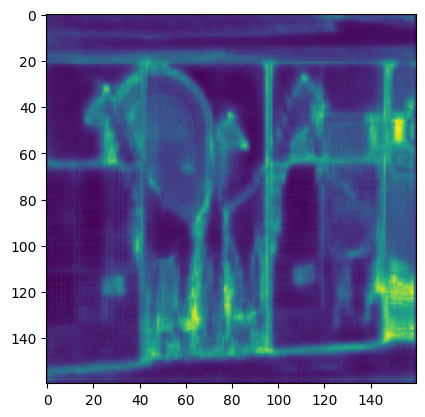

In [160]:
# uncertainty Estimation: Finally DONE
inputs_, i = torch.min(dist_val, -1) # find the minimal angle values for each points. 
input_to_plot = (inputs_[bs] -  inputs_[bs].min())/(inputs_[bs].max() -  inputs_[bs].min())
plt.imshow(torch.exp(input_to_plot.cpu()*2))
plt.savefig('figure/'+'ade3_uq_dist'+'.svg', format = 'svg')

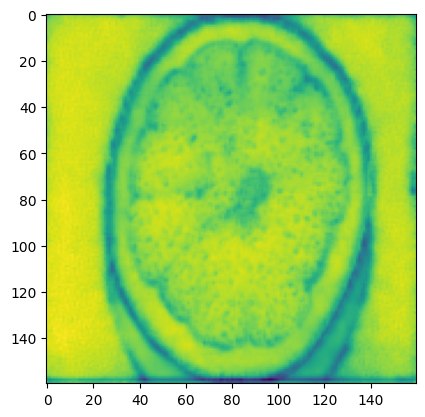

In [71]:
# inputs_= -angle_val.permute(0,3,1,2)[:,6:7,:,:].detach()  -aangle_valval.permute(0,3,1,2)[:,67:68,:,:].detach()  -angle_val.permute(0,3,1,2)[:,26:27,:,:].detach()

indices = [10]
inputs_ = -dist_val.permute(0, 3, 1, 2)[:, indices, :, :].detach().sum(dim=1, keepdim=True)
# inputs_= outputs.masks_queries_logits[:,1:2,:,:].detach().sigmoid()
input_to_plot = (inputs_[bs] -  inputs_[bs].min())/(inputs_[bs].max() -  inputs_[bs].min())

input_to_plot = input_to_plot**1

plt.imshow(input_to_plot.cpu().permute(1,2,0)); plt.show()

In [72]:
dist_val.shape

torch.Size([16, 160, 160, 100])

In [105]:
mul_val = ((dist_val.permute(0,3,1,2)) * outputs.masks_queries_logits.sigmoid())
mag_val =  dist_val.pow(2).sum(3).sqrt()
mag_val.shape

torch.Size([16, 160, 160])

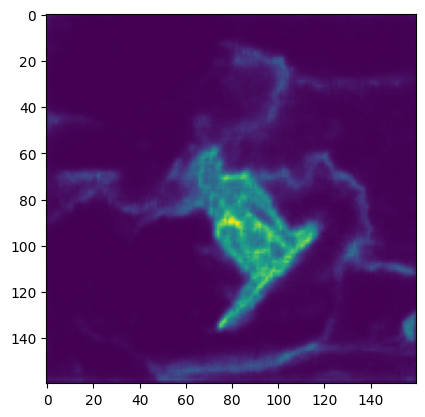

In [106]:
inputs_= mag_val.detach()
input_to_plot = (inputs_[bs] -  inputs_[bs].min())/(inputs_[bs].max() -  inputs_[bs].min())
# input_to_plot = torch.exp(input_to_plot)
input_to_plot = input_to_plot**3
plt.imshow(input_to_plot.cpu()); plt.show()

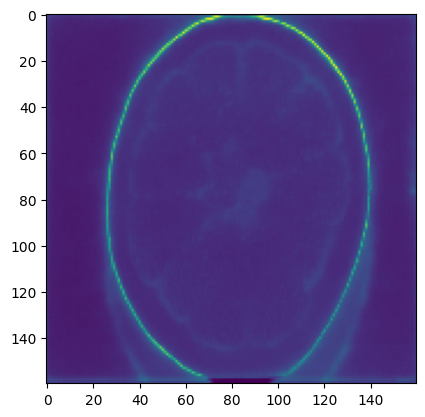

In [75]:
indices = [69, 73, 9, 0]
inputs_ = mul_val[:, indices, :, :].detach().sum(dim=1, keepdim=True)

input_to_plot = (inputs_[bs] -  inputs_[bs].min())/(inputs_[bs].max() -  inputs_[bs].min())

# input_to_plot = torch.exp(input_to_plot/5)

input_to_plot = input_to_plot ** 2

plt.imshow(input_to_plot.cpu().permute(1,2,0)); plt.show()

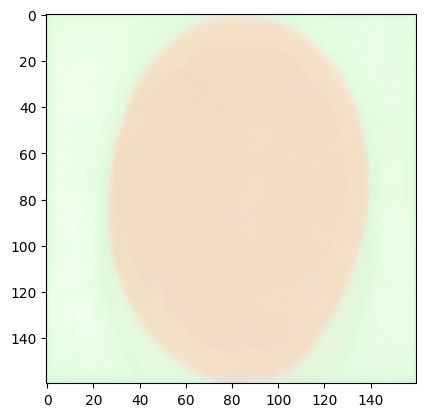

In [77]:
inputs_= -angle_val.permute(0,3,1,2)[:,indices,:,:].detach() 
# inputs_= outputs.masks_queries_logits[:,1:2,:,:].detach().sigmoid()

input_to_plot = (inputs_[bs] -  inputs_[bs].min())/(inputs_[bs].max() -  inputs_[bs].min())

input_to_plot = input_to_plot**0.5

plt.imshow(input_to_plot.cpu().permute(1,2,0)); plt.show()

In [111]:
inputs_.shape

torch.Size([16, 1, 160, 160])

In [455]:
# manual test of text prototypes.
t_feat = text_feats_pca[:,0,:]
t_feat_exp = L.exp_map0(t_feat/0.3)
dist_mat = L.pairwise_dist(t_feat_exp, t_feat_exp)
torch.min(-dist_mat.fill_diagonal_(0))
angle_mat = L.oxy_angle_full(t_feat_exp, t_feat_exp)
l_product = L.pairwise_inner(t_feat_exp, t_feat_exp)
torch.min(angle_mat[0][0].fill_diagonal_(5))

tensor(2.2506)

In [456]:
l_product[0]

tensor([ -1.0000, -30.6921, -34.6511, -35.8402, -30.1737, -32.0681, -36.8782,
        -30.8900, -28.8177, -29.5396, -31.7824, -28.7579, -38.1652, -23.8328,
        -33.2108, -37.1917, -26.1956, -26.6853, -43.3898, -24.5093, -38.5374,
        -34.6015, -30.1819, -38.7997, -28.6455, -23.1335, -38.0374, -27.4764,
        -26.6439, -28.7172, -28.8444, -30.3930, -30.0146, -21.6743, -24.9330,
        -29.6219, -31.2572, -26.8769, -27.1317, -25.4621, -32.6817, -25.8886,
        -24.4881, -24.7979, -36.9638, -35.2904, -27.4468, -28.5217, -31.2844,
        -32.5075, -35.3088, -31.1101, -34.9720, -24.9482, -29.1143, -36.3133,
        -32.1347, -37.8938, -32.2115, -35.4964, -26.9277, -35.7562, -31.1261,
        -29.4766, -25.8200, -27.4001, -25.0457, -29.8193, -29.5512, -50.7264,
        -29.9205, -24.8314, -28.9772, -39.9050, -25.5884, -36.9934, -28.0370,
        -25.6777, -43.4610, -40.1908, -22.8660, -40.5044, -26.8089, -35.4476,
        -33.1645, -27.8577, -28.5093, -27.9040, -27.5168, -29.77

In [ ]:
### Extra Codes: Not required


In [487]:
print("hyperbolicity test: delete it later")
print(outputs.keys())
print(outputs.encoder_last_hidden_state.shape)
print(outputs.decoder_last_hidden_state.shape)
print(len(outputs.decoder_hidden_states))
outputs.decoder_hidden_states[0].shape

hyperbolicity test: delete it later
odict_keys(['encoder_last_hidden_state', 'decoder_last_hidden_state', 'decoder_hidden_states'])
torch.Size([16, 1024, 20, 20])
torch.Size([16, 256, 160, 160])
3


torch.Size([16, 256, 20, 20])

In [492]:
print("hyperbolicity test: delete it later")

re_feats = outputs.decoder_last_hidden_state.permute(0,2,3,1)
re_feats = re_feats.reshape(-1, re_feats.shape[-1]).cpu()
idx = np.random.choice(len(re_feats), 2000)
all_features_small = re_feats[idx]
all_features_small.shape

hyperbolicity test: delete it later


torch.Size([2000, 256])

In [493]:
print("hyperbolicity test: delete it later")

def delta_hyp_torch(dismat):
    p = 0
    row = dismat[p, :][None, :]
    col = dismat[:, p][:, None]
    XY_p = 0.5 * (row + col - dismat)
    maxmin = torch.minimum(XY_p[:, :, None], XY_p[None, :, :]).max(1).values
    return (maxmin - XY_p).max()

import numpy as np


# dists = distance_matrix(all_features_small, all_features_small)
dists = torch.cdist(all_features_small, all_features_small)
delta = delta_hyp_torch(dists)
diam = torch.max(dists)
del_rel =  2*delta/diam
print('delta relative: ', del_rel)
c = (0.144 / del_rel) ** 2
print('c value: ', c)


hyperbolicity test: delete it later
delta relative:  tensor(0.3848)
c value:  tensor(0.1401)
